# Job-Market Skill Mining for Curriculum Design

## Setup

### Import Python libraries

In [1]:
import numpy as np
import pandas as pd
import os
import requests
import matplotlib as plt
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from sklearn.preprocessing import normalize
import scipy.cluster.hierarchy as sch
#from scipy import zeros as sci_zeros
from scipy.spatial.distance import euclidean
from scipy.cluster.hierarchy import ClusterWarning
from warnings import simplefilter

simplefilter("ignore", ClusterWarning)

In [3]:
from scipy.cluster.hierarchy import fcluster
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [4]:
from openai import OpenAI
from dotenv import load_dotenv
import os

load_dotenv()
api_key = os.getenv('OPENAI_API_KEY')
if not api_key:
    raise ValueError('OPENAI_API_KEY not found. Add it to .env in the repo root.')

model = 'gpt-5'
client = OpenAI(api_key=api_key)


### Load Job Postings

In [5]:
filename_data = 'webscraping_results_job_market.csv'
results = pd.read_csv(filename_data)
results.rename(columns={'Job_Title': 'Title', 'Company_Name': 'Company', 'Description': 'Descriptions'}, inplace=True)

In [6]:
results

,Title,Company,Location,Rating,Date,Salary,Descriptions,Links
0,Data Analyst,Highnote,"San Francisco, CA",NaN,NaN,"$120,000 - $170,000a year",About Highnote\nFounded in 2020 by a team of l...,https://www.indeed.com/rc/clk?jk=0db6b2300349e...
1,Senior Data Analyst (Data Science),SpotOn: Corporate,"San Francisco, CA",NaN,NaN,"$130,000 - $175,000a year",About SpotOn\nWe're not just building restaura...,https://www.indeed.com/rc/clk?jk=53d789c0b11fc...
2,Senior Data Analyst (Data Science),SpotOn: Corporate,"San Francisco, CA",NaN,NaN,"$130,000 - $175,000a year",Description not found,https://www.indeed.com/viewjob?jk=abcdef012345...
3,Data Analyst,10000 Degrees,"Hybrid work in San Rafael, CA 94903",NaN,NaN,"$83,000 - $95,000a year",Description:\nTITLE\n: Data Analyst\nREGION\n:...,https://www.indeed.com/rc/clk?jk=78036be52b5ac...
4,Data Analyst,Minted,"Hybrid work in San Francisco, CA 94115",NaN,NaN,"$95,244 - $125,139a year",The Role:\nMinted is a marketplace that connec...,https://www.indeed.com/rc/clk?jk=355982a9934c8...
...,...,...,...,...,...,...,...,...
1072,Machine Learning Graduate (eCommerce Recommend...,ByteDance,"Seattle, WA",NaN,NaN,"$112,725 - $177,840a year",Location:\nSeattle\nTeam:\nTechnology\nEmploym...,https://www.indeed.com/rc/clk?jk=0cab5244890fd...
1073,"Backend Software Engineer, LiveOps",BRINC,"Hybrid work in Seattle, WA",NaN,NaN,"$142,000 - $250,000a year","About BRINC:\nAt BRINC, we are redefining publ...",https://www.indeed.com/rc/clk?jk=103a658223f2a...
1074,Machine Learning Engineer - Inference,ByteDance,"Seattle, WA",NaN,NaN,"$198,360 - $416,100a year",Location:\nSeattle\nTeam:\nTechnology\nEmploym...,https://www.indeed.com/rc/clk?jk=96719358f726e...
1075,Research Software Engineer,Accutar Biotechnology,"Bellevue, WA",NaN,NaN,"$200,000a year",Design and develop drug discovery software. De...,https://www.indeed.com/rc/clk?jk=fad071d6cc15e...


## Data Processing and Feature Engineering

### GPT Recommend Skills

In [ ]:
prompt_1 = """
I am building a curriculum for a Master of Business and Management in Data Science and AI.
Based on your knowledge of current job postings across the roles:
- data analyst
- data scientist
- business analyst
- machine learning engineer

Generate a comprehensive and up-to-date list of skills required in these roles.

Requirements for your output:
1. Group skills into clear categories such as:
 - Programming
 - Machine Learning / AI
 - Data Engineering
 - Statistics & Mathematics
 - Business
 - Visualization
 - Cloud
 - Soft Skills / Professional Skills

2. For each category, output the **AT MOST top 5 most frequently appearing skills** in job postings.

3. Return the result **ONLY** as a valid Python dictionary named `skill_dict`,
 where keys are category names (strings) and values are lists of skill names (strings).

4. Ensure the dictionary follows proper syntax so it can be copied directly into Python code.

Do not include explanations outside the dictionary.
"""

response_1 = client.chat.completions.create(
 model = model,
 messages = [
 {"role": "system", "content": "You are an expert on data science and AI job markets."},
 {"role": "user", "content": prompt_1}
 ]
)

output_1 = response_1.choices[0].message.content

print(output_1)

skill_dict = {
 "Programming": ["Python", "SQL", "R", "Git", "Java/Scala"],
 "Machine Learning / AI": ["Supervised and unsupervised learning", "Feature engineering", "Model evaluation and validation", "Deep learning (PyTorch or TensorFlow)", "LLMs and GenAI (prompting, RAG)"],
 "Data Engineering": ["SQL", "ETL/ELT", "Data warehousing (Snowflake, BigQuery, Redshift)", "Apache Airflow", "Apache Spark"],
 "Statistics & Mathematics": ["Probability and statistical inference", "Hypothesis testing and experimental design (A/B tests)", "Regression modeling", "Time series analysis", "Linear algebra and optimization"],
 "Business": ["Business acumen and domain knowledge", "Requirements gathering and translation", "KPI definition and performance measurement", "Stakeholder management and storytelling", "Product thinking and experimentation"],
 "Visualization": ["Excel (advanced)", "Tableau", "Power BI", "Looker", "matplotlib/seaborn"],
 "Cloud": ["AWS", "Azure", "Google Cloud (GCP)", "Docker", "Ku

To avoid potential loss, the GPT-generated output is saved in the cell below.

In [ ]:
skill_dict = {
 "Programming": [
 "Python", 
 "SQL", 
 "R", 
 "Git", 
 "Java/Scala"],
 "Machine Learning / AI": [
 "Supervised and unsupervised learning", 
 "Feature engineering", 
 "Model evaluation and validation", 
 "Deep learning (PyTorch or TensorFlow)", 
 "LLMs and GenAI (prompting, RAG)"],
 "Data Engineering": [
 "SQL", 
 "ETL/ELT", 
 "Data warehousing (Snowflake, BigQuery, Redshift)", 
 "Apache Airflow", 
 "Apache Spark"],
 "Statistics & Mathematics": [
 "Probability and statistical inference", 
 "Hypothesis testing and experimental design (A/B tests)", 
 "Regression modeling", 
 "Time series analysis", 
 "Linear algebra and optimization"],
 "Business": [
 "Business acumen and domain knowledge", 
 "Requirements gathering and translation", 
 "KPI definition and performance measurement", 
 "Stakeholder management and storytelling", 
 "Product thinking and experimentation"],
 "Visualization": [
 "Excel (advanced)", 
 "Tableau", 
 "Power BI", 
 "Looker", 
 "matplotlib/seaborn"],
 "Cloud": [
 "AWS", 
 "Azure", 
 "Google Cloud (GCP)", 
 "Docker", 
 "Kubernetes"],
 "Soft Skills / Professional Skills": [
 "Communication (written and verbal)", 
 "Stakeholder management and influence", 
 "Problem solving and critical thinking", 
 "Collaboration and cross-functional teamwork", 
 "Project management (Agile/Scrum)"]
}

So far, ``skill_dict`` is not used directly. Additional skills have been added based on the content from Lecture 8, including `Machine learning`, `Artificial intelligence`, `Hadoop`, `Big Data`, `Consulting`, and `Negotiation`.

In [7]:
# Programming / systems skills
prog_skills = {}
prog_skills['Python'] = []
prog_skills['SQL'] = []
prog_skills['R'] = []
prog_skills['Git'] = []
prog_skills['Java/Scala'] = []

# ML/AI skills
ml_skills = {}
ml_skills['Supervised and unsupervised learning'] = []
ml_skills['Feature engineering'] = []
ml_skills['Model evaluation and validation'] = []
ml_skills['Deep learning'] = []
ml_skills['LLMs and GenAI'] = []
ml_skills['Machine learning'] = []
ml_skills['Artificial intelligence'] = []

# Data engineering skills
de_skills = {}
de_skills['ETL/ELT'] = []
de_skills['Data warehousing'] = []
de_skills['Apache Airflow'] = []
de_skills['Apache Spark'] = []
de_skills['Hadoop'] = []
de_skills['Big Data'] = []

# Statistics / mathematics skills
st_skills = {}
st_skills['Probability and statistical inference'] = []
st_skills['Experimental design'] = []
st_skills['Regression modeling'] = []
st_skills['Time series analysis'] = []
st_skills['Linear algebra and optimization'] = []

# Business skills
bu_skills = {}
bu_skills['Business acumen'] = []
bu_skills['Requirements gathering'] = []
bu_skills['KPI definition'] = []
bu_skills['Stakeholder management'] = []
bu_skills['Product thinking'] = []
bu_skills['Consulting'] = []

# Visualization skills
vi_skills = {}
vi_skills['Excel'] = []
vi_skills['Tableau'] = []
vi_skills['Power BI'] = []
vi_skills['Looker'] = []
vi_skills['matplotlib_seaborn'] = []

# Professional / soft skills
pro_skills = {}
pro_skills['Communication'] = []
pro_skills['Problem solving'] = []
pro_skills['Teamwork'] = []
pro_skills['Project management'] = []
pro_skills['Negotiation'] = []

# Cloud skills
cl_skills = {}
cl_skills['AWS'] = []
cl_skills['Azure'] = []
cl_skills['GCP'] = []
cl_skills['Docker'] = []
cl_skills['Kubernetes'] = []

ChatGPT was used to generate additional string-matching conditions for extracting skills.

In [8]:
for ir, dfr in results.iterrows():

 cleantext = str(dfr["Descriptions"]).lower()

 # =========================================
 # PROGRAMMING
 # =========================================
 # Python
 if ("python" in cleantext) or ("py " in cleantext) or ("jupyter" in cleantext) \
 or (".ipynb" in cleantext) or ("notebook" in cleantext):
 prog_skills['Python'].append('1')
 else:
 prog_skills['Python'].append('0')

 # SQL
 if ("sql" in cleantext) or ("structured query" in cleantext) or ("mysql" in cleantext) \
 or ("postgres" in cleantext) or ("postgresql" in cleantext) or ("tsql" in cleantext):
 prog_skills['SQL'].append('1')
 else:
 prog_skills['SQL'].append('0')

 # R language
 if (" r " in cleantext) or (" r," in cleantext) or ("rstudio" in cleantext) \
 or ("tidyverse" in cleantext) or (" r/" in cleantext) or (" r-" in cleantext) \
 or (" r." in cleantext) or ("programming in r"):
 prog_skills['R'].append('1')
 else:
 prog_skills['R'].append('0')

 # Git
 if ("git" in cleantext) or ("github" in cleantext) or ("version control" in cleantext):
 prog_skills['Git'].append('1')
 else:
 prog_skills['Git'].append('0')

 # Java / Scala
 if ("java" in cleantext) or ("scala" in cleantext) or ("jvm" in cleantext):
 prog_skills['Java/Scala'].append('1')
 else:
 prog_skills['Java/Scala'].append('0')


 # =========================================
 # MACHINE LEARNING / AI
 # =========================================

 # Supervised + Unsupervised
 if ("supervised" in cleantext) or ("unsupervised" in cleantext) \
 or ("classification" in cleantext) or ("clustering" in cleantext):
 ml_skills['Supervised and unsupervised learning'].append('1')
 else:
 ml_skills['Supervised and unsupervised learning'].append('0')

 # Feature engineering
 if ("feature engineering" in cleantext) or ("feature extraction" in cleantext) \
 or ("feature selection" in cleantext):
 ml_skills['Feature engineering'].append('1')
 else:
 ml_skills['Feature engineering'].append('0')

 # Model evaluation
 if ("model evaluation" in cleantext) or ("validation" in cleantext) \
 or ("cross-validation" in cleantext) or ("confusion matrix" in cleantext):
 ml_skills['Model evaluation and validation'].append('1')
 else:
 ml_skills['Model evaluation and validation'].append('0')

 # Deep learning
 if ("deep learning" in cleantext) or ("neural network" in cleantext) \
 or ("cnn" in cleantext) or ("rnn" in cleantext) or ("transformer" in cleantext):
 ml_skills['Deep learning'].append('1')
 else:
 ml_skills['Deep learning'].append('0')

 # LLMs & GenAI
 if ("llm" in cleantext) or ("generative ai" in cleantext) or ("gpt" in cleantext) \
 or ("rag" in cleantext) or ("prompt engineering" in cleantext):
 ml_skills['LLMs and GenAI'].append('1')
 else:
 ml_skills['LLMs and GenAI'].append('0')
 
 # Machine learning
 if ("machine learning" in cleantext) or ("ml model" in cleantext) \
 or ("ml pipeline" in cleantext) or ("ml " in cleantext):
 ml_skills['Machine learning'].append('1')
 else:
 ml_skills['Machine learning'].append('0')
 
 # Artificial intelligence
 if ("artificial intelligence" in cleantext) or ("ai solution" in cleantext) \
 or ("ai system" in cleantext) or ("ai " in cleantext):
 ml_skills['Artificial intelligence'].append('1')
 else:
 ml_skills['Artificial intelligence'].append('0')


 # =========================================
 # DATA ENGINEERING
 # =========================================

 # ETL / ELT
 if ("etl" in cleantext) or ("elt" in cleantext) or ("data pipeline" in cleantext) \
 or ("ingestion" in cleantext):
 de_skills['ETL/ELT'].append('1')
 else:
 de_skills['ETL/ELT'].append('0')

 # Data warehousing
 if ("snowflake" in cleantext) or ("redshift" in cleantext) or ("bigquery" in cleantext) \
 or ("warehouse" in cleantext) or ("star schema" in cleantext):
 de_skills['Data warehousing'].append('1')
 else:
 de_skills['Data warehousing'].append('0')

 # Airflow
 if "airflow" in cleantext:
 de_skills['Apache Airflow'].append('1')
 else:
 de_skills['Apache Airflow'].append('0')

 # Spark
 if ("spark" in cleantext) or ("pyspark" in cleantext):
 de_skills['Apache Spark'].append('1')
 else:
 de_skills['Apache Spark'].append('0')
 
 # Big Data
 if ("big data" in cleantext) or ("distributed computing" in cleantext) \
 or ("large-scale data" in cleantext):
 de_skills['Big Data'].append('1')
 else:
 de_skills['Big Data'].append('0')

 # Hadoop
 if ("hadoop" in cleantext):
 de_skills['Hadoop'].append('1')
 else:
 de_skills['Hadoop'].append('0')

 # =========================================
 # STATISTICS / MATHEMATICS
 # =========================================

 # Probability / Statistics
 if ("probab" in cleantext) or ("statistical" in cleantext) \
 or ("bayesian" in cleantext) or ("frequentist" in cleantext) \
 or ("probability" in cleantext) or ("statistics" in cleantext):
 st_skills['Probability and statistical inference'].append('1')
 else:
 st_skills['Probability and statistical inference'].append('0')

 # A/B testing, experiments
 if ("a/b" in cleantext) or ("ab test" in cleantext) or ("experiment" in cleantext) \
 or ("controlled test" in cleantext):
 st_skills['Experimental design'].append('1')
 else:
 st_skills['Experimental design'].append('0')

 # Regression
 if ("regression" in cleantext) or ("linear model" in cleantext):
 st_skills['Regression modeling'].append('1')
 else:
 st_skills['Regression modeling'].append('0')

 # Time series
 if ("time series" in cleantext) or ("forecasting" in cleantext) \
 or ("arima" in cleantext):
 st_skills['Time series analysis'].append('1')
 else:
 st_skills['Time series analysis'].append('0')

 # Optimization
 if ("optimization" in cleantext) or ("linear algebra" in cleantext) \
 or ("gradient descent" in cleantext):
 st_skills['Linear algebra and optimization'].append('1')
 else:
 st_skills['Linear algebra and optimization'].append('0')


 # =========================================
 # BUSINESS SKILLS
 # =========================================

 if ("business" in cleantext) or ("domain knowledge" in cleantext):
 bu_skills['Business acumen'].append('1')
 else:
 bu_skills['Business acumen'].append('0')

 if ("requirement" in cleantext) or ("requirements" in cleantext) \
 or ("specification" in cleantext):
 bu_skills['Requirements gathering'].append('1')
 else:
 bu_skills['Requirements gathering'].append('0')

 if ("kpi" in cleantext) or ("metric" in cleantext) or ("performance indicator" in cleantext):
 bu_skills['KPI definition'].append('1')
 else:
 bu_skills['KPI definition'].append('0')

 if "stakeholder" in cleantext:
 bu_skills['Stakeholder management'].append('1')
 else:
 bu_skills['Stakeholder management'].append('0')

 if ("product" in cleantext) and ("manager" not in cleantext):
 bu_skills['Product thinking'].append('1')
 else:
 bu_skills['Product thinking'].append('0')

 # consulting
 if ("consulting" in cleantext) or ("consultant" in cleantext) \
 or ("advisory" in cleantext):
 bu_skills['Consulting'].append('1')
 else:
 bu_skills['Consulting'].append('0')

 # =========================================
 # VISUALIZATION
 # =========================================

 if "excel" in cleantext:
 vi_skills['Excel'].append('1')
 else:
 vi_skills['Excel'].append('0')

 if "tableau" in cleantext:
 vi_skills['Tableau'].append('1')
 else:
 vi_skills['Tableau'].append('0')

 if "power bi" in cleantext:
 vi_skills['Power BI'].append('1')
 else:
 vi_skills['Power BI'].append('0')

 if ("looker" in cleantext) or ("looker studio" in cleantext):
 vi_skills['Looker'].append('1')
 else:
 vi_skills['Looker'].append('0')

 if ("matplotlib" in cleantext) or ("seaborn" in cleantext):
 vi_skills['matplotlib_seaborn'].append('1')
 else:
 vi_skills['matplotlib_seaborn'].append('0')
 
 # =========================================
 # SOFT SKILLS / PROFESSIONAL SKILLS
 # =========================================

 if ("communication" in cleantext) or ("presentation" in cleantext):
 pro_skills['Communication'].append('1')
 else:
 pro_skills['Communication'].append('0')

 if ("problem solving" in cleantext) or ("critical thinking" in cleantext) \
 or ("analytical thinking" in cleantext):
 pro_skills['Problem solving'].append('1')
 else:
 pro_skills['Problem solving'].append('0')

 if "team" in cleantext:
 pro_skills['Teamwork'].append('1')
 else:
 pro_skills['Teamwork'].append('0')

 if ("project management" in cleantext) or ("agile" in cleantext) \
 or ("scrum" in cleantext) or ("kanban" in cleantext):
 pro_skills['Project management'].append('1')
 else:
 pro_skills['Project management'].append('0')

 if ("negotiation" in cleantext) or ("negotiating" in cleantext) \
 or ("negotiate" in cleantext):
 pro_skills['Negotiation'].append('1')
 else:
 pro_skills['Negotiation'].append('0')

 # =========================================
 # CLOUD SKILLS
 # =========================================

 if ("aws" in cleantext) or ("amazon web services" in cleantext):
 cl_skills['AWS'].append('1')
 else:
 cl_skills['AWS'].append('0')

 if "azure" in cleantext:
 cl_skills['Azure'].append('1')
 else:
 cl_skills['Azure'].append('0')

 if ("gcp" in cleantext) or ("google cloud" in cleantext):
 cl_skills['GCP'].append('1')
 else:
 cl_skills['GCP'].append('0')

 if ("docker" in cleantext) or ("container" in cleantext):
 cl_skills['Docker'].append('1')
 else:
 cl_skills['Docker'].append('0')

 if ("kubernetes" in cleantext) or ("k8s" in cleantext) \
 or ("container orchestration" in cleantext):
 cl_skills['Kubernetes'].append('1')
 else:
 cl_skills['Kubernetes'].append('0')

In [9]:
df = results[['Title', 'Company', 'Location', 'Salary', 'Descriptions']].copy()
df_prog = pd.DataFrame(prog_skills)
df_ml = pd.DataFrame(ml_skills)
df_de = pd.DataFrame(de_skills)
df_st = pd.DataFrame(st_skills)
df_bu = pd.DataFrame(bu_skills)
df_vi = pd.DataFrame(vi_skills)
df_pro = pd.DataFrame(pro_skills)
df_cl = pd.DataFrame(cl_skills)

frames = [df, df_prog, df_ml, df_de, df_st, df_bu, df_vi, df_pro, df_cl]

res = pd.concat(frames, axis = 1)
res.head()

,Title,Company,Location,Salary,Descriptions,Python,SQL,R,Git,Java/Scala,...,Communication,Problem solving,Teamwork,Project management,Negotiation,AWS,Azure,GCP,Docker,Kubernetes
0,Data Analyst,Highnote,"San Francisco, CA","$120,000 - $170,000a year",About Highnote\nFounded in 2020 by a team of l...,1,1,1,1,1,...,0,0,1,0,0,1,0,0,0,0
1,Senior Data Analyst (Data Science),SpotOn: Corporate,"San Francisco, CA","$130,000 - $175,000a year",About SpotOn\nWe're not just building restaura...,1,1,1,0,1,...,0,0,1,0,0,0,0,0,0,0
2,Senior Data Analyst (Data Science),SpotOn: Corporate,"San Francisco, CA","$130,000 - $175,000a year",Description not found,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Data Analyst,10000 Degrees,"Hybrid work in San Rafael, CA 94903","$83,000 - $95,000a year",Description:\nTITLE\n: Data Analyst\nREGION\n:...,0,0,1,0,0,...,1,0,1,0,0,0,0,0,0,0
4,Data Analyst,Minted,"Hybrid work in San Francisco, CA 94115","$95,244 - $125,139a year",The Role:\nMinted is a marketplace that connec...,1,1,1,1,0,...,1,0,1,0,0,1,0,0,0,0


In [10]:
df_skills = res.iloc[:,5:]
df_summary = df_skills.apply(pd.to_numeric)
a = df_summary.values

print("Number of job postings:", a.shape[0])
print(a)

Number of job postings: 1077
[[1 1 1 ... 0 0 0]
 [1 1 1 ... 0 0 0]
 [0 0 1 ... 0 0 0]
 ...
 [0 0 1 ... 0 0 0]
 [1 0 1 ... 1 0 0]
 [1 0 1 ... 0 0 0]]


Visualization will be finished at the end of the notebook.

## Hierarchical Clustering

In [11]:
skill_vectors = a.T
skill_vectors_norm = normalize(skill_vectors, axis=1)
num_skills = skill_vectors_norm.shape[0]

D = np.zeros((num_skills, num_skills))

for i in range(num_skills):
 for j in range(num_skills):
 D[i, j] = euclidean(skill_vectors_norm[i], skill_vectors_norm[j])

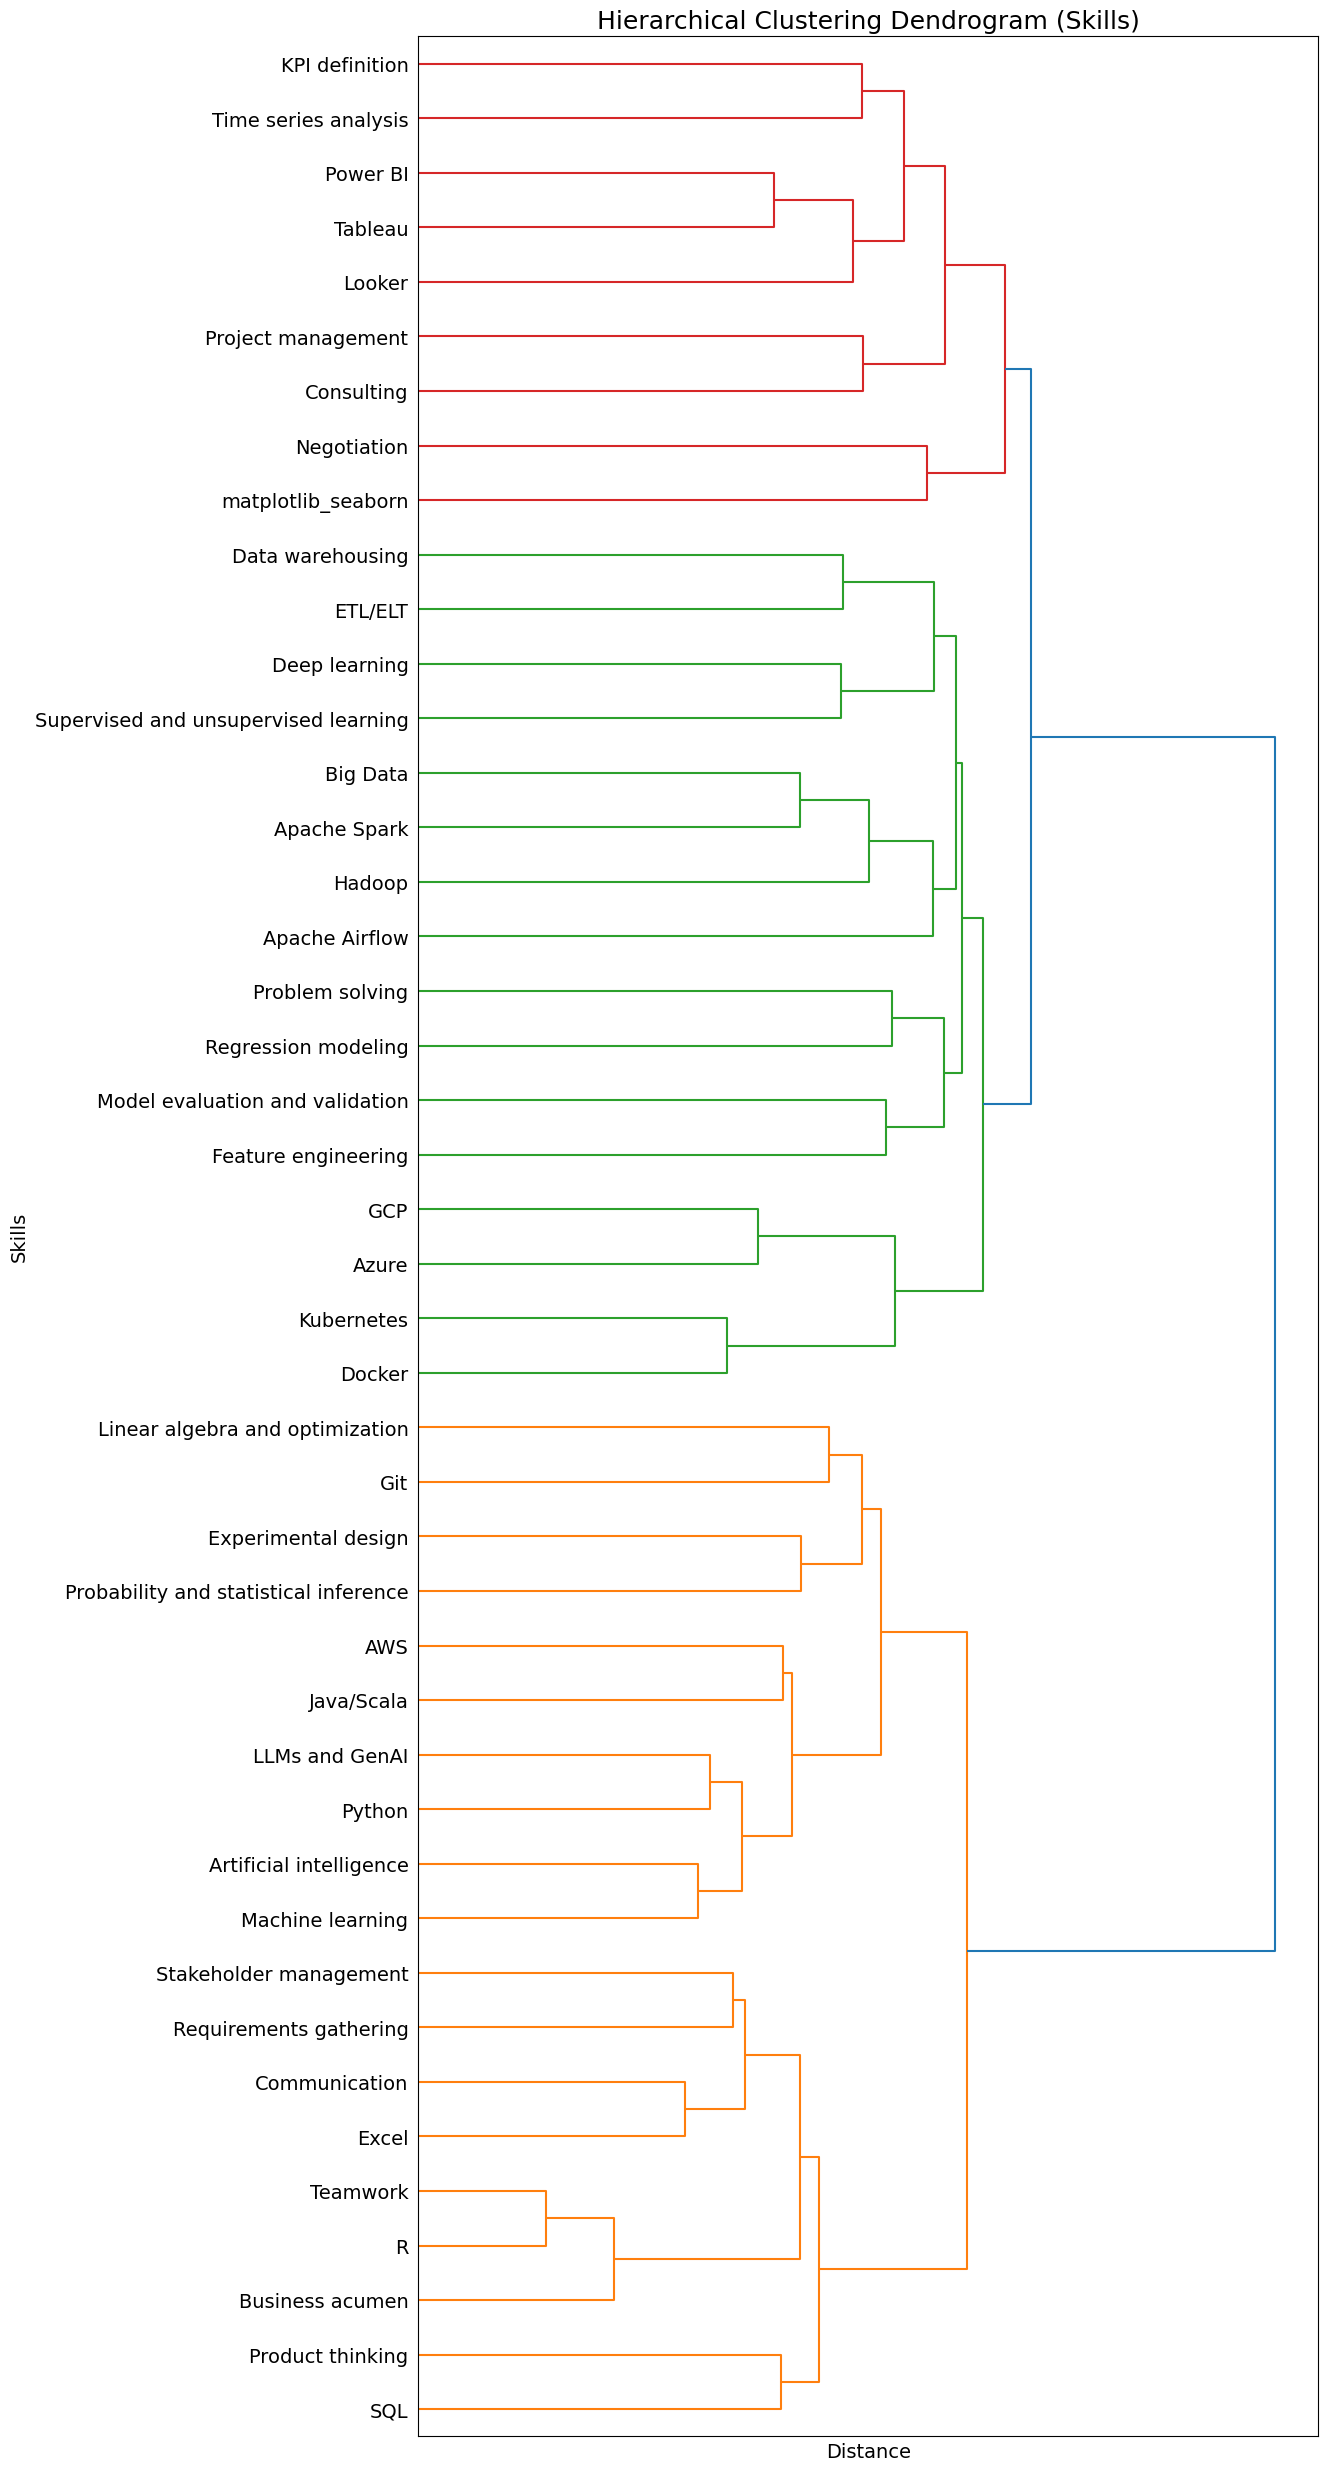

In [12]:
Y = sch.linkage(D, method='complete')

skill_names = df_skills.columns.tolist()

fig = plt.figure(figsize=(15, 30))
ax = fig.add_axes([0.1, 0.1, 0.6, 0.8])

Z = sch.dendrogram(Y, orientation='right')

labels = [skill_names[i] for i in Z['leaves']]

ax.set_xticks([])
ax.set_yticklabels(labels, fontsize=14)

plt.title("Hierarchical Clustering Dendrogram (Skills)", fontsize=18)
plt.xlabel("Distance", fontsize=14)
plt.ylabel("Skills", fontsize=14)

plt.show()

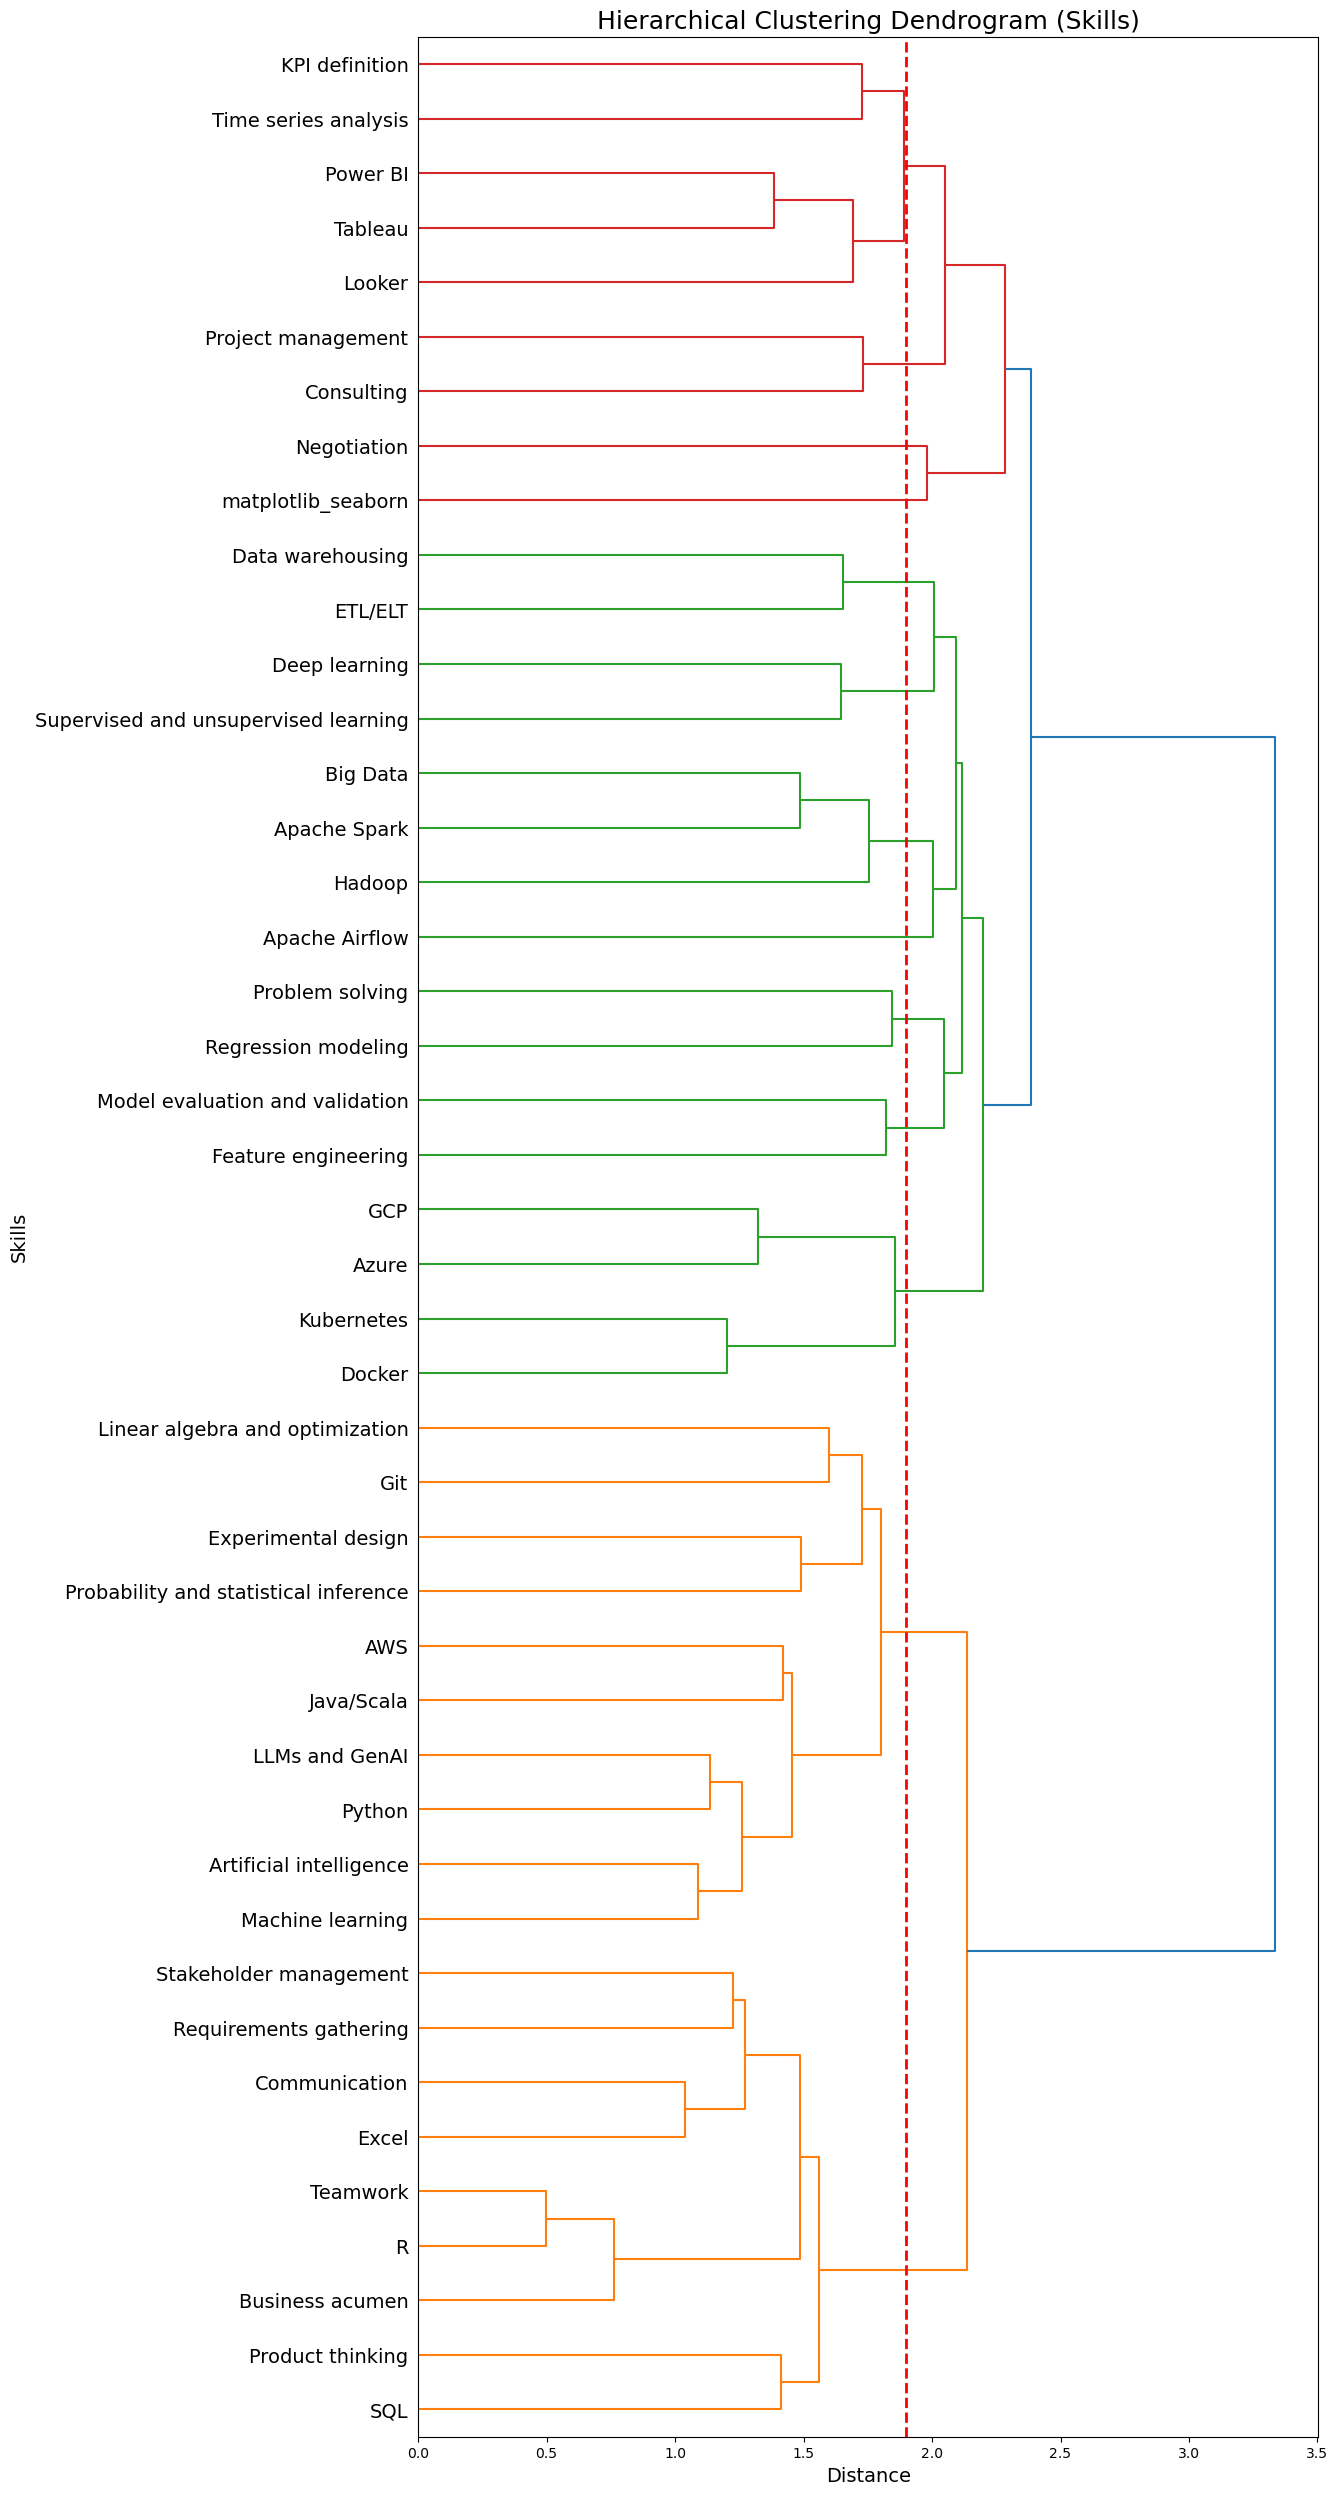

In [13]:
max_d = 1.9

fig = plt.figure(figsize=(15, 30))
ax = fig.add_axes([0.1, 0.1, 0.6, 0.8])

Z = sch.dendrogram(Y, orientation='right')

labels = [skill_names[i] for i in Z['leaves']]

ax.set_yticklabels(labels, fontsize=14)

plt.axvline(x=max_d, color='red', linestyle='--', linewidth=2)

plt.title("Hierarchical Clustering Dendrogram (Skills)", fontsize=18)
plt.xlabel("Distance", fontsize=14)
plt.ylabel("Skills", fontsize=14)

plt.savefig("figures/hierarchical.png", dpi=600, bbox_inches='tight')

plt.show()

In [14]:
labels_all = fcluster(Y, max_d, criterion='distance')

clusters = {}
for skill, c in zip(skill_names, labels_all):
 clusters.setdefault(c, []).append(skill)

clusters_sorted = dict(sorted(clusters.items(), key=lambda x: -len(x[1])))

print(f"{len(clusters_sorted)} clusters formed:\n")
for cid, skills in clusters_sorted.items():
 print(f"Cluster {cid} ({len(skills)} skills):")
 print(" " + ", ".join(skills))
 print()


13 clusters formed:

Cluster 2 (10 skills):
 Python, Git, Java/Scala, LLMs and GenAI, Machine learning, Artificial intelligence, Probability and statistical inference, Experimental design, Linear algebra and optimization, AWS

Cluster 1 (9 skills):
 SQL, R, Business acumen, Requirements gathering, Stakeholder management, Product thinking, Excel, Communication, Teamwork

Cluster 13 (5 skills):
 Time series analysis, KPI definition, Tableau, Power BI, Looker

Cluster 3 (4 skills):
 Azure, GCP, Docker, Kubernetes

Cluster 6 (3 skills):
 Apache Spark, Hadoop, Big Data

Cluster 8 (2 skills):
 Supervised and unsupervised learning, Deep learning

Cluster 4 (2 skills):
 Feature engineering, Model evaluation and validation

Cluster 9 (2 skills):
 ETL/ELT, Data warehousing

Cluster 5 (2 skills):
 Regression modeling, Problem solving

Cluster 12 (2 skills):
 Consulting, Project management

Cluster 7 (1 skills):
 Apache Airflow

Cluster 10 (1 skills):
 matplotlib_seaborn

Cluster 11 (1 skills):
 N

Adjust the skills in more reasonable clusters.

In [15]:
adjusted_clusters = {
 1: [ # 2 + 5
 "Python",
 "Git",
 "Java/Scala",
 "LLMs and GenAI",
 "Machine learning",
 "Artificial intelligence",
 "Probability and statistical inference",
 "Experimental design",
 "Linear algebra and optimization",
 "AWS",
 "Regression modeling",
 "Problem solving"
 ],
 2: [ # 1
 "SQL",
 "R",
 "Business acumen",
 "Requirements gathering",
 "Stakeholder management",
 "Product thinking",
 "Excel",
 "Communication",
 "Teamwork"
 ],
 3: [ # 13 + 10
 "Time series analysis",
 "KPI definition",
 "Tableau",
 "Power BI",
 "Looker",
 "matplotlib_seaborn"
 ],
 4: [ # 3
 "Azure",
 "GCP",
 "Docker",
 "Kubernetes"
 ],
 5: [ # 6 + 7 + 9
 "Apache Spark",
 "Hadoop",
 "Big Data",
 "Apache Airflow",
 "ETL/ELT",
 "Data warehousing"
 ],
 6: [ # 8
 "Supervised and unsupervised learning",
 "Deep learning"
 ],
 7: [ # 4
 "Feature engineering",
 "Model evaluation and validation"
 ],
 8: [ # 12 + 11
 "Consulting",
 "Project management",
 "Negotiation"
 ]
}

In [16]:
# Build skill to cluster mapping
skill_to_cluster = {}
for cid, skills in adjusted_clusters.items():
 for s in skills:
 skill_to_cluster[s] = cid

cluster_labels_adjusted = [skill_to_cluster[s] for s in skill_names]

In [17]:
sil_score = silhouette_score(D, cluster_labels_adjusted, metric='precomputed')
print("max_d =", max_d)
print("Adjusted Clustering Silhouette Score:", sil_score)

max_d = 1.9
Adjusted Clustering Silhouette Score: 0.03570374564889369


The manually adjusted 8-cluster track achieves a silhouette score of $0.036$ with `max_d = 1.9` better than other manual adjust clustering in different `max_d` settings. Still the score is relatively low due to splitting and adding skills to the cluster.

## K-means or DBSCAN Clustering 

### Feature Engineering

In [18]:
# Annual Salary Function

import re

def parse_salary_to_annual(s):
 if pd.isna(s):
 return np.nan
 
 text = str(s)

 # Find numbers
 nums = re.findall(r'[\d,]+', text)
 if not nums:
 return np.nan
 
 values = [int(n.replace(',', '')) for n in nums]
 salary = np.mean(values)

 text_lower = text.lower()

 if 'hour' in text_lower:
 return salary * 40 * 52
 else:
 return salary

In [19]:
skills = df_summary.columns.tolist()
skill_feature_rows = []

for skill in skills:
 mask = df_summary[skill] == 1
 n_skill = mask.sum()

 row = {'skill': skill}
 row['skill_freq'] = int(n_skill)

 if n_skill == 0: # if no postings with this skill
 for f in ['mean_cooccur','max_cooccur','n_locations','remote_share',
 'avg_salary','avg_desc_len',
 'title_signal_tech','title_signal_business','title_signal_senior']:
 row[f] = 0
 skill_feature_rows.append(row)
 continue

 df_skill = res[mask]
 df_skill_skills = df_summary[mask]

 # Co-occurrence Features
 co = df_skill_skills.sum(axis=1) - 1
 row['mean_cooccur'] = float(co.mean())
 row['max_cooccur'] = int(co.max())

 # Location Features
 locs = df_skill['Location'].astype(str)
 row['n_locations'] = int(locs.nunique()) # num of unique locations
 row['remote_share'] = float(
 locs.str.contains('remote|hybrid', regex=True, case=False).mean()
 ) # percentage remote/hybrid

 # Salary Feature
 if 'Salary' in df_skill.columns:
 salary_num = df_skill['Salary'].apply(parse_salary_to_annual)
 valid = salary_num.notna()
 row['avg_salary'] = float(salary_num.mean()) if valid.sum() > 0 else 0.0
 else:
 row['avg_salary'] = 0.0

 # Description Length Feature
 desc_len = df_skill['Descriptions'].astype(str).str.split().str.len()
 row['avg_desc_len'] = float(desc_len.mean())

 # Technical Title Feature
 titles = df_skill['Title'].astype(str)
 row['title_signal_tech'] = float(
 titles.str.contains(
 r'data|analyst|engineer|scientist|machine learning|ai',
 case=False, regex=True
 ).mean()
 )

 # Business Titles Feature
 row['title_signal_business'] = float(
 titles.str.contains(
 r'manager|consultant|business|specialist|coordinator',
 case=False, regex=True
 ).mean()
 )

 # Seniority Title Feature
 row['title_signal_senior'] = float(
 titles.str.contains(
 r'senior|sr\.|lead|manager|director|principal',
 case=False,
 regex=True
 ).mean()
 )

 skill_feature_rows.append(row)

skill_features = pd.DataFrame(skill_feature_rows).set_index('skill')
skill_features

,skill_freq,mean_cooccur,max_cooccur,n_locations,remote_share,avg_salary,avg_desc_len,title_signal_tech,title_signal_business,title_signal_senior
skill,,,,,,,,,,
Python,573,14.069808,27,134,0.635253,165485.675399,765.160558,0.947644,0.143106,0.523560
SQL,496,13.584677,26,130,0.618952,146060.408840,704.939516,0.947581,0.252016,0.433468
R,1077,11.323120,27,257,0.588672,144775.707474,659.025998,0.930362,0.297122,0.424327
Git,264,14.291667,27,88,0.655303,159392.544118,780.507576,0.939394,0.204545,0.560606
Java/Scala,402,14.410448,27,107,0.606965,165309.184543,806.447761,0.925373,0.159204,0.547264
Supervised and unsupervised learning,143,16.258741,27,43,0.524476,162846.166667,878.622378,0.965035,0.083916,0.475524
Feature engineering,44,15.613636,25,18,0.522727,204282.615385,636.681818,1.000000,0.159091,0.454545
Model evaluation and validation,154,13.733766,25,56,0.551948,173663.358491,799.292208,0.974026,0.240260,0.428571
Deep learning,157,14.433121,27,45,0.560510,183004.796000,812.554140,0.980892,0.114650,0.560510


### K-Mean Clustering

In [20]:
X = skill_features.values.astype(float)
X = np.nan_to_num(X, nan=0.0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Shape of X_scaled:", X_scaled.shape)

Shape of X_scaled: (44, 10)


In [21]:
k_values = range(2, 15)
inertias = []

for k in k_values:
 kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
 labels_k = kmeans.fit_predict(X_scaled)
 
 inertias.append(kmeans.inertia_)
 print(f"k = {k:2d}, inertia = {kmeans.inertia_:8.2f}")


k = 2, inertia = 396.55
k = 3, inertia = 271.55
k = 4, inertia = 217.71
k = 5, inertia = 182.23
k = 6, inertia = 141.53
k = 7, inertia = 120.23
k = 8, inertia = 111.12
k = 9, inertia = 102.18
k = 10, inertia = 90.66
k = 11, inertia = 82.26
k = 12, inertia = 73.76
k = 13, inertia = 66.46
k = 14, inertia = 61.60


c:\Users\13820\anaconda3\envs\myenv\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
 warnings.warn(
c:\Users\13820\anaconda3\envs\myenv\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
 warnings.warn(
c:\Users\13820\anaconda3\envs\myenv\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
 warnings.warn(
c:\Users\13820\anaconda3\envs\myenv\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans

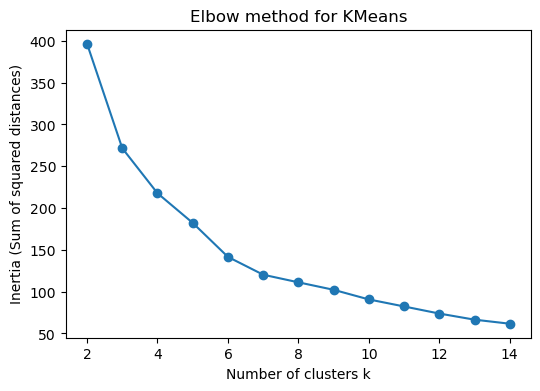

In [22]:
plt.figure(figsize=(6,4))
plt.plot(list(k_values), inertias, marker='o')

plt.xlabel("Number of clusters k")
plt.ylabel("Inertia (Sum of squared distances)")
plt.title("Elbow method for KMeans")

plt.savefig("figures/elbow.png", dpi=600, bbox_inches='tight')

plt.show()

Therefore we choose $6$ as best cluster, but still need to be adjusted manually.

In [23]:
best_k = 6

kmeans_final = KMeans(n_clusters=best_k, n_init='auto', random_state=42)
skill_cluster_labels = kmeans_final.fit_predict(X_scaled)

c:\Users\13820\anaconda3\envs\myenv\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
 warnings.warn(


In [24]:
labels_kmeans = skill_cluster_labels
skill_names = skill_features.index.tolist()

clusters_kmeans = {}
for skill, cid in zip(skill_names, labels_kmeans):
 clusters_kmeans.setdefault(cid, []).append(skill)

clusters_kmeans_sorted = dict(sorted(clusters_kmeans.items(),
 key=lambda x: -len(x[1])))

print(f"{len(clusters_kmeans_sorted)} clusters formed:\n")
for cid, skills in clusters_kmeans_sorted.items():
 print(f"Cluster {cid} ({len(skills)} skills):")
 print(" " + ", ".join(skills))
 print()

6 clusters formed:

Cluster 1 (21 skills):
 Git, Java/Scala, Supervised and unsupervised learning, Model evaluation and validation, Deep learning, Machine learning, Artificial intelligence, ETL/ELT, Data warehousing, Apache Airflow, Apache Spark, Big Data, Probability and statistical inference, Experimental design, Regression modeling, Linear algebra and optimization, AWS, Azure, GCP, Docker, Kubernetes

Cluster 2 (11 skills):
 Python, SQL, R, LLMs and GenAI, Business acumen, Requirements gathering, Stakeholder management, Product thinking, Excel, Communication, Teamwork

Cluster 5 (8 skills):
 Time series analysis, KPI definition, Consulting, Tableau, Power BI, Looker, Problem solving, Project management

Cluster 0 (2 skills):
 Feature engineering, Hadoop

Cluster 3 (1 skills):
 matplotlib_seaborn

Cluster 4 (1 skills):
 Negotiation



Manually adjust the cluster:

In [25]:
kmean_adjusted_clusters = {
 0:[ # from 1 + 2
 "Git",
 "Java/Scala",
 "Python", 
 "SQL",
 "R",
 ],

 1:[ # from 1 + 5
 "Probability and statistical inference",
 "Experimental design",
 "Regression modeling",
 "Linear algebra and optimization",
 "Time series analysis",
 ],

 2:[ # from 1 + 0 + 2
 "Supervised and unsupervised learning", 
 "Model evaluation and validation", 
 "Deep learning", 
 "Machine learning", 
 "Artificial intelligence",
 "Feature engineering",
 "LLMs and GenAI",
 ],

 3:[ # from 1 + 0
 "ETL/ELT", 
 "Data warehousing",
 "Apache Airflow", 
 "Apache Spark", 
 "Big Data", 
 "Hadoop",
 ],

 4:[ # from 1
 "AWS", 
 "Azure", 
 "GCP", 
 "Docker", 
 "Kubernetes", 
 ],

 5:[ # from 5 + 2 + 3
 "KPI definition", 
 "Tableau", 
 "Power BI", 
 "Looker",
 "Excel",
 "matplotlib_seaborn",
 ],

 6:[ # from 2 + 5
 "Business acumen", 
 "Requirements gathering",
 "Stakeholder management",
 "Product thinking", 
 "Project management", 
 "Problem solving",
 ],

 7:[ # from 2 + 5 + 4
 "Communication",
 "Teamwork", 
 "Consulting", 
 "Negotiation",
 ]

}

In [26]:
skill_names = skill_features.index.tolist()

adjusted_labels = []
for skill in skill_names:
 assigned = None
 for cid, skills in kmean_adjusted_clusters.items():
 if skill in skills:
 assigned = cid
 break
 adjusted_labels.append(assigned)

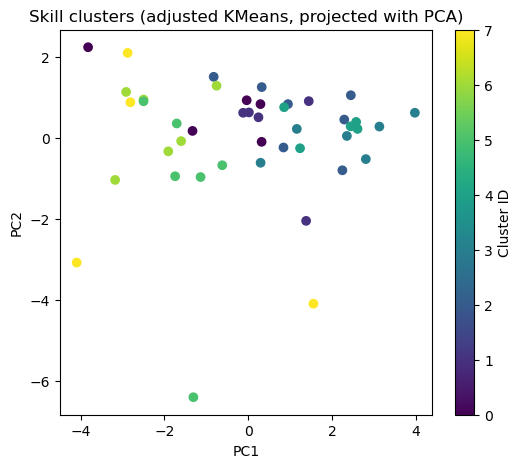

In [27]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6, 5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
 c=adjusted_labels,)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Skill clusters (adjusted KMeans, projected with PCA)")
plt.colorbar(scatter, label="Cluster ID")

plt.savefig("figures/PCA.png", dpi=600, bbox_inches='tight')
plt.show()


In [28]:
sil_adjusted = silhouette_score(X_scaled, adjusted_labels)
print("Silhouette score for adjusted clusters (K-Mean):", sil_adjusted)

Silhouette score for adjusted clusters (K-Mean): -0.09024858617616399


Both the PCA visualization and the silhouette score indicate that the manually adjusted clusters are not well separated geometrically. PCA shows the chosen clusters overlap significantly, which is confirmed by Silhouette score of $-0.0902$. It is expected since the adjusted clusters were created by splitting and merging the optimal 6 clusters. 

## Visualization

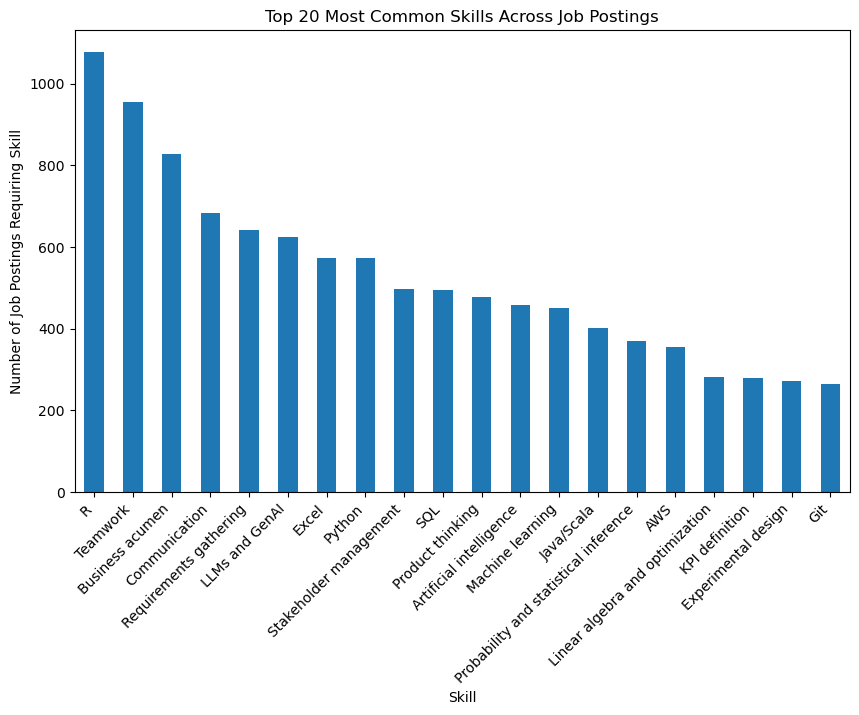

In [29]:
skill_counts = df_summary.sum(axis=0).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
skill_counts.head(20).plot(kind='bar')

plt.xlabel("Skill")
plt.ylabel("Number of Job Postings Requiring Skill")
plt.title("Top 20 Most Common Skills Across Job Postings")
plt.xticks(rotation=45, ha='right')

plt.savefig("figures/top_20_skills.png", dpi=600, bbox_inches='tight')

plt.show()

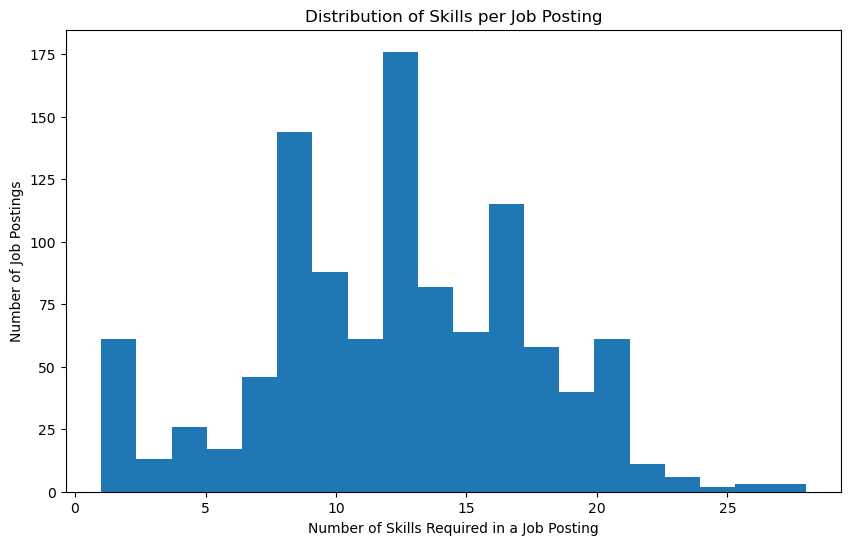

In [30]:
skills_per_job = df_summary.sum(axis=1)

plt.figure(figsize=(10, 6))
plt.hist(skills_per_job, bins=20)

plt.xlabel("Number of Skills Required in a Job Posting")
plt.ylabel("Number of Job Postings")
plt.title("Distribution of Skills per Job Posting")

plt.savefig("figures/hist_skills.png", dpi=600, bbox_inches='tight')

plt.show()

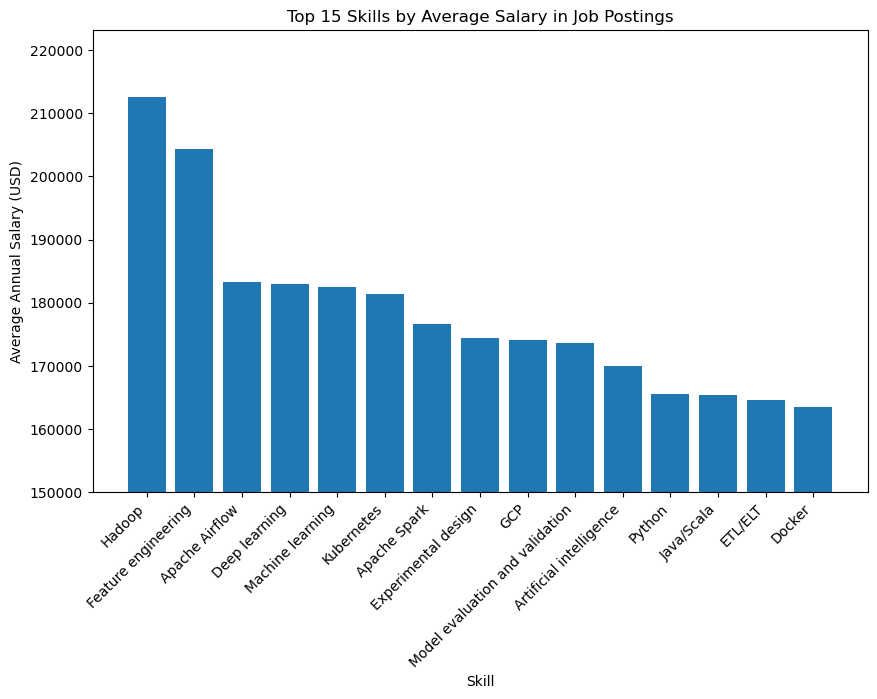

In [31]:
sf_salary = skill_features.copy()
sf_salary_nonzero = sf_salary[sf_salary['avg_salary'] > 0]
top_salary = sf_salary_nonzero.sort_values('avg_salary', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.bar(top_salary.index, top_salary['avg_salary'])

plt.ylim(150000,)

plt.xlabel("Skill")
plt.ylabel("Average Annual Salary (USD)")
plt.title("Top 15 Skills by Average Salary in Job Postings")
plt.xticks(rotation=45, ha='right')

plt.savefig("figures/top_15_salary.png", dpi=600, bbox_inches='tight')

plt.show()

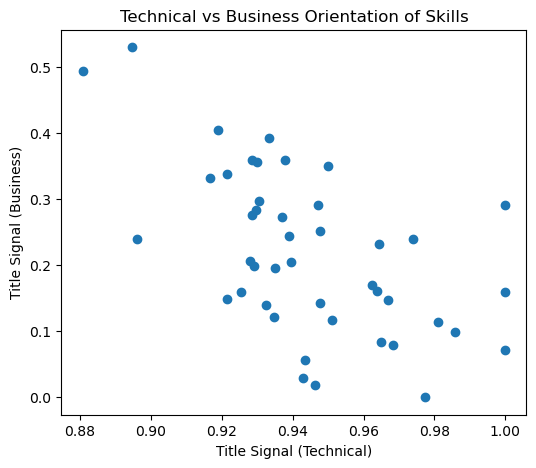

In [32]:
plt.figure(figsize=(6, 5))
plt.scatter(
 skill_features['title_signal_tech'],
 skill_features['title_signal_business']
)

plt.xlabel("Title Signal (Technical)")
plt.ylabel("Title Signal (Business)")
plt.title("Technical vs Business Orientation of Skills")

plt.savefig("figures/ts_vs_bs.png", dpi=600, bbox_inches='tight')

plt.show()

## Combine Results

In [33]:
clusters_h = adjusted_clusters
clusters_k = kmean_adjusted_clusters

In [34]:
clusters_h

{1: ['Python',
 'Git',
 'Java/Scala',
 'LLMs and GenAI',
 'Machine learning',
 'Artificial intelligence',
 'Probability and statistical inference',
 'Experimental design',
 'Linear algebra and optimization',
 'AWS',
 'Regression modeling',
 'Problem solving'],
 2: ['SQL',
 'R',
 'Business acumen',
 'Requirements gathering',
 'Stakeholder management',
 'Product thinking',
 'Excel',
 'Communication',
 'Teamwork'],
 3: ['Time series analysis',
 'KPI definition',
 'Tableau',
 'Power BI',
 'Looker',
 'matplotlib_seaborn'],
 4: ['Azure', 'GCP', 'Docker', 'Kubernetes'],
 5: ['Apache Spark',
 'Hadoop',
 'Big Data',
 'Apache Airflow',
 'ETL/ELT',
 'Data warehousing'],
 6: ['Supervised and unsupervised learning', 'Deep learning'],
 7: ['Feature engineering', 'Model evaluation and validation'],
 8: ['Consulting', 'Project management', 'Negotiation']}

In [35]:
clusters_k

{0: ['Git', 'Java/Scala', 'Python', 'SQL', 'R'],
 1: ['Probability and statistical inference',
 'Experimental design',
 'Regression modeling',
 'Linear algebra and optimization',
 'Time series analysis'],
 2: ['Supervised and unsupervised learning',
 'Model evaluation and validation',
 'Deep learning',
 'Machine learning',
 'Artificial intelligence',
 'Feature engineering',
 'LLMs and GenAI'],
 3: ['ETL/ELT',
 'Data warehousing',
 'Apache Airflow',
 'Apache Spark',
 'Big Data',
 'Hadoop'],
 4: ['AWS', 'Azure', 'GCP', 'Docker', 'Kubernetes'],
 5: ['KPI definition',
 'Tableau',
 'Power BI',
 'Looker',
 'Excel',
 'matplotlib_seaborn'],
 6: ['Business acumen',
 'Requirements gathering',
 'Stakeholder management',
 'Product thinking',
 'Project management',
 'Problem solving'],
 7: ['Communication', 'Teamwork', 'Consulting', 'Negotiation']}

In [36]:
h_map = {skill: cid - 1 for cid, skills in clusters_h.items() for skill in skills}
k_map = {skill: cid for cid, skills in clusters_k.items() for skill in skills}

ensemble = {}
for skill in h_map.keys():
 votes = (h_map[skill], k_map.get(skill, -1))
 final_cluster = max(set(votes), key=votes.count)
 ensemble.setdefault(final_cluster, []).append(skill)

ensemble

{0: ['Python',
 'Git',
 'Java/Scala',
 'LLMs and GenAI',
 'Machine learning',
 'Artificial intelligence',
 'Probability and statistical inference',
 'Experimental design',
 'Linear algebra and optimization',
 'AWS',
 'Regression modeling',
 'Problem solving',
 'SQL',
 'R'],
 1: ['Business acumen',
 'Requirements gathering',
 'Stakeholder management',
 'Product thinking',
 'Excel',
 'Communication',
 'Teamwork',
 'Time series analysis'],
 2: ['KPI definition',
 'Tableau',
 'Power BI',
 'Looker',
 'matplotlib_seaborn',
 'Supervised and unsupervised learning',
 'Deep learning',
 'Feature engineering',
 'Model evaluation and validation'],
 3: ['Azure',
 'GCP',
 'Docker',
 'Kubernetes',
 'Apache Spark',
 'Hadoop',
 'Big Data',
 'Apache Airflow',
 'ETL/ELT',
 'Data warehousing'],
 7: ['Consulting', 'Negotiation'],
 6: ['Project management']}

The ensemble voting approach produced large cluster which is less meaningful compared to the previous 2 groups of clusters. Therefore we still choose the hierarchical cluster as the best result.

## Interpretation of Results Using ChatGPT API

In [37]:
final_tracks = clusters_h
input_skills = ""
for i, topics in final_tracks.items():
 input_skills += f"Track {i}: " + ", ".join(topics) + "; \n"
input_skills = input_skills[:-2]
print(input_skills)

Track 1: Python, Git, Java/Scala, LLMs and GenAI, Machine learning, Artificial intelligence, Probability and statistical inference, Experimental design, Linear algebra and optimization, AWS, Regression modeling, Problem solving; 
Track 2: SQL, R, Business acumen, Requirements gathering, Stakeholder management, Product thinking, Excel, Communication, Teamwork; 
Track 3: Time series analysis, KPI definition, Tableau, Power BI, Looker, matplotlib_seaborn; 
Track 4: Azure, GCP, Docker, Kubernetes; 
Track 5: Apache Spark, Hadoop, Big Data, Apache Airflow, ETL/ELT, Data warehousing; 
Track 6: Supervised and unsupervised learning, Deep learning; 
Track 7: Feature engineering, Model evaluation and validation; 
Track 8: Consulting, Project management, Negotiation;


In [ ]:
prompt_2 = (
 "You are a university curriculum designer. \n"
 "Write a short, compelling program description (150-200 words) "
 "for a Master of Business and Management in Data "
 "Science and AI based on these tracks:\n\n"
 f"{input_skills}\n\n"
 "Highlight career outcomes and why this curriculum prepares students for real industry roles."
)

response_2 = client.chat.completions.create(
 model=model,
 messages=[{"role": "user", "content": prompt_2}]
)

print(response_2.choices[0].message.content)

Turn data into decisions—and impact—through our Master of Business and Management in Data Science and AI. This industry-shaped program blends technical depth with business leadership. Build a rigorous foundation in Python, Git, Java/Scala, probability and statistical inference, experimental design, linear algebra and optimization, regression modeling, and modern ML/AI, including LLMs and GenAI. Develop analytics fluency with SQL, R, Excel, time series analysis, KPI definition, and compelling storytelling using Tableau, Power BI, Looker, and matplotlib/seaborn.

Learn to ship value in real environments: design ETL/ELT and data warehousing, orchestrate pipelines with Apache Airflow, scale Big Data on Apache Spark and Hadoop, and deploy to AWS, Azure, and GCP with Docker and Kubernetes. Strengthen product thinking, business acumen, requirements gathering, stakeholder management, consulting, project management, negotiation, and communication—so your models move from notebooks to the boardr

**GPT's outcome is pasted below in case for losing:**

Turn data into decisions—and impact—through our Master of Business and Management in Data Science and AI. This industry-shaped program blends technical depth with business leadership. Build a rigorous foundation in Python, Git, Java/Scala, probability and statistical inference, experimental design, linear algebra and optimization, regression modeling, and modern ML/AI, including LLMs and GenAI. Develop analytics fluency with SQL, R, Excel, time series analysis, KPI definition, and compelling storytelling using Tableau, Power BI, Looker, and matplotlib/seaborn.

Learn to ship value in real environments: design ETL/ELT and data warehousing, orchestrate pipelines with Apache Airflow, scale Big Data on Apache Spark and Hadoop, and deploy to AWS, Azure, and GCP with Docker and Kubernetes. Strengthen product thinking, business acumen, requirements gathering, stakeholder management, consulting, project management, negotiation, and communication—so your models move from notebooks to the boardroom.

Graduate prepared for roles such as data scientist, machine learning engineer, analytics or BI lead, data engineer, AI/ML product manager, or data/AI consultant. With hands-on problem solving, supervised and unsupervised learning, deep learning, feature engineering, and rigorous model evaluation and validation, you’ll be ready to deliver measurable outcomes—at scale and with cross-functional teams.

In [124]:
prompt_3 = (
 "You are an expert on data science and AI job markets. \n"
 "Analyze the following curriculum for alignment with industry standards in "
 "data science, data and business analytics, machine learning and AI roles. "
 "Identify strengths and essential skills, or missing skills and any important gaps in the curriculum. "
 "Write a short report in 300-400 words:\n\n"
 f"{input_skills}"
)

response_3 = client.chat.completions.create(
 model=model,
 messages=[{"role": "user", "content": prompt_3}]
)

print(response_3.choices[0].message.content)

Overall alignment
The curriculum covers most core competencies expected across data science, analytics, ML/AI, and data engineering roles: programming (Python, SQL, R), math/stats foundations, ML (classical and deep), cloud platforms (AWS/Azure/GCP), big-data tooling (Spark/Hadoop), orchestration (Airflow), BI/visualization, and key soft skills (communication, stakeholder management, product thinking). This breadth maps well to entry-to-mid roles in data science, ML engineering, analytics, and parts of data engineering.

Strengths
- Strong foundations: Python, statistics/inference, linear algebra/optimization, regression, supervised/unsupervised learning, feature engineering, model evaluation.
- Practical analytics: SQL, Excel, KPI definition, time series, experimentation, product/stakeholder skills, Tableau/Power BI/Looker, matplotlib/seaborn.
- Production-oriented stack: Git, Docker/Kubernetes, multi-cloud, Spark/Hadoop, Airflow, warehousing.
- GenAI exposure: LLMs/GenAI included; go

**GPT's outcome is pasted below in case for losing:**

- **Overall alignment** <br>
 The curriculum covers most core competencies expected across data science, analytics, ML/AI, and data engineering roles: programming (Python, SQL, R), math/stats foundations, ML (classical and deep), cloud platforms (AWS/Azure/GCP), big-data tooling (Spark/Hadoop), orchestration (Airflow), BI/visualization, and key soft skills (communication, stakeholder management, product thinking). This breadth maps well to entry-to-mid roles in data science, ML engineering, analytics, and parts of data engineering.

- **Strengths**
 - Strong foundations: Python, statistics/inference, linear algebra/optimization, regression, supervised/unsupervised learning, feature engineering, model evaluation.
 - Practical analytics: SQL, Excel, KPI definition, time series, experimentation, product/stakeholder skills, Tableau/Power BI/Looker, matplotlib/seaborn.
 - Production-oriented stack: Git, Docker/Kubernetes, multi-cloud, Spark/Hadoop, Airflow, warehousing.
 - GenAI exposure: LLMs/GenAI included; good signal of currency.
 - Professional skills: communication, consulting, project management, negotiation—valuable for product/analytics roles.

- **Important gaps and recommendations**
 - MLOps and production ML: add model serving (batch/online), model monitoring/drift, experiment tracking (MLflow), feature stores, deployment patterns, lineage, and CI/CD for ML; include platform examples (SageMaker, Vertex AI, Kubeflow).
 - Software engineering for data/ML: testing (unit/integration, data/ML tests), packaging, logging/observability, API design (REST/gRPC), dependency/env management, code review standards.
 - Analytics engineering and data modeling: dimensional modeling (star/snowflake), dbt and data testing, data contracts, SQL performance tuning, query optimization.
 - Data reliability and streaming: data quality frameworks (Great Expectations), observability/SLAs, event streaming (Kafka, Spark/Flink streaming).
 - Responsible and compliant AI: bias/fairness, explainability, model governance, privacy/PII handling, security, and regulatory basics (GDPR/CCPA, model risk management).
 - Advanced experimentation/causal inference: power analysis, CUPED, sequential tests, uplift modeling, propensity scoring, diff-in-diff, Bayesian A/B testing.
 - GenAI/LLMOps depth: embeddings, vector databases (FAISS/Pinecone), RAG architectures, prompt engineering and evaluation, fine-tuning/PEFT, cost/performance/safety guardrails.
 - Visualization/storytelling: dashboard UX principles, narrative with data, experiment result communication and decision-making.
 - Domain and business analytics: cohort/funnel analysis, CLV/churn, pricing/marketing attribution, marketplace/recs; ties skills to business impact.
 - Portfolio/capstone: end-to-end projects demonstrating data acquisition → modeling → deployment/monitoring, with reproducible repos and dashboards.

If these gaps are addressed, the program would align strongly with current industry standards from analyst through ML/AI engineer levels.

In [127]:
prompt_4 = (
 "You are a university curriculum designer. \n"
 "Review the following tracks and recommend prerequisite relationships between the tracks. "
 "Identify which tracks should logically come earlier or later, and "
 "propose an optimal sequencing for a one or two year master's program.\n"
 "Write a short report in 200-300 words:\n\n"
 f"{input_skills}"
)

response_4 = client.chat.completions.create(
 model=model,
 messages=[{"role": "user", "content": prompt_4}]
)

print(response_4.choices[0].message.content)

Short rationale
Track 1 supplies programming, math, and core ML foundations; Track 2 adds SQL, R, and business/communication needed for analytics and stakeholder work. tracks 3 and 7 apply those foundations to analysis/visualization and model-building rigor. Track 6 deepens ML (DL). Track 4 introduces cloud/container platforms needed to operate at scale. Track 5 builds data engineering pipelines and warehouses atop cloud and SQL. Track 8 is best when students already have technical breadth and stakeholder context.

Key prerequisite relationships
- Track 1 -> tracks 3, 4, 5, 6, 7
- Track 2 (SQL/R) -> tracks 3, 5; (business/communication) -> Track 8
- Track 7 -> Track 6 (or strong co-requisite)
- Track 4 -> Track 5 (or co-requisite)
- tracks 1+2 -> Capstone/Consulting (8); Track 3 recommended before capstone for KPI/viz

One-year (3-term) intensive sequence
- Term 1: Track 1, Track 2
- Term 2: Track 7, Track 6, Track 4
- Term 3: Track 5, Track 3, Track 8 + capstone integrating cloud, big

**GPT's outcome is pasted below in case for losing:**

- **Short rationale** <br>
Track 1 supplies programming, math, and core ML foundations; Track 2 adds SQL, R, and business/communication needed for analytics and stakeholder work. tracks 3 and 7 apply those foundations to analysis/visualization and model-building rigor. Track 6 deepens ML (DL). Track 4 introduces cloud/container platforms needed to operate at scale. Track 5 builds data engineering pipelines and warehouses atop cloud and SQL. Track 8 is best when students already have technical breadth and stakeholder context.

- **Key prerequisite relationships**
 - Track 1 -> tracks 3, 4, 5, 6, 7
 - Track 2 (SQL/R) -> tracks 3, 5; (business/communication) -> Track 8
 - Track 7 -> Track 6 (or strong co-requisite)
 - Track 4 -> Track 5 (or co-requisite)
 - tracks 1+2 -> Capstone/Consulting (8); Track 3 recommended before capstone for KPI/viz

- **One-year (3-term) intensive sequence**
 - Term 1: Track 1, Track 2
 - Term 2: Track 7, Track 6, Track 4
 - Term 3: Track 5, Track 3, Track 8 + capstone integrating cloud, big data, KPIs, and stakeholder delivery

- **Two-year (4-term) sequence**
 - Year 1 Fall: Track 1, Track 2
 - Year 1 Spring: Track 3, Track 4
 - Year 2 Fall: Track 7, Track 6
 - Year 2 Spring: Track 5, Track 8 + capstone (end-to-end data product using Spark/Airflow on cloud, with KPIs and stakeholder management)

- **Notes**
 - Track 3 benefits from prior SQL/R (Track 2) and Python/stats (Track 1).
 - Place time series (Track 3) before capstone to ground KPI definition and dashboards.
 - LLMs/GenAI (in Track 1) can be revisited as elective modules within Track 6 or the capstone.